# Step 2: Exploratory Data Analysis

**Project:** Spotify Music Recommendation System
**Phase:** 2 of 4 — Exploratory Data Analysis

## What this notebook does

Now that both datasets have been loaded and validated (see
`01_reading_data.ipynb`), this notebook explores what they actually
contain. The goal isn't to build any models yet — it's to understand the
data well enough that the modeling choices in Steps 3 and 4 are informed
by evidence rather than guesswork.

This notebook covers three things:

1. **How the sound of music has changed over the decades** (audio-features dataset)
2. **Which genres and artists are most prominent**, and how popularity relates
   to other attributes (genre & metadata dataset)
3. **Word clouds** for genres and artists, as a quick visual summary

All charts are also saved to `../outputs/figures/`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import ast
import os

sns.set_theme(style="whitegrid")
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")


In [2]:
audio_df = pd.read_csv("../data/raw/spotify_tracks.csv")
genre_df = pd.read_csv("../data/raw/spotify_genre_metadata.csv")

print(f"Audio-features dataset: {audio_df.shape[0]:,} tracks")
print(f"Genre & metadata dataset: {genre_df.shape[0]:,} tracks")


Audio-features dataset: 169,909 tracks
Genre & metadata dataset: 8,778 tracks


## 2.1 How has the sound of music changed over the decades?

To answer this, we group tracks by the decade they were released in, then
look at the average value of each audio feature per decade. This turns
170,000 individual songs into a small number of trend lines we can
actually read.

In [3]:
audio_df["decade"] = (audio_df["year"] // 10) * 10

decade_trends = audio_df.groupby("decade")[
    ["danceability", "energy", "valence", "acousticness", "loudness", "tempo"]
].mean()

decade_trends


,danceability,energy,valence,acousticness,loudness,tempo
decade,,,,,,
1920,0.577000,0.240642,0.566615,0.830644,-16.224082,110.172327
1930,0.536202,0.288124,0.576027,0.875116,-13.995736,111.976689
1940,0.471628,0.253416,0.485126,0.870705,-15.450652,107.340219
1950,0.477069,0.287032,0.476691,0.840150,-14.792113,110.601903
1960,0.496651,0.415796,0.556918,0.621166,-12.737268,115.473647
1970,0.526920,0.538544,0.587902,0.392206,-11.388174,120.126717
1980,0.549658,0.602475,0.570081,0.286104,-11.129206,121.488896
1990,0.571790,0.594565,0.549937,0.292137,-9.851969,119.333221
2000,0.576234,0.658571,0.533421,0.258534,-7.365055,121.360571


Saved: ../outputs/figures\decade_trends.png


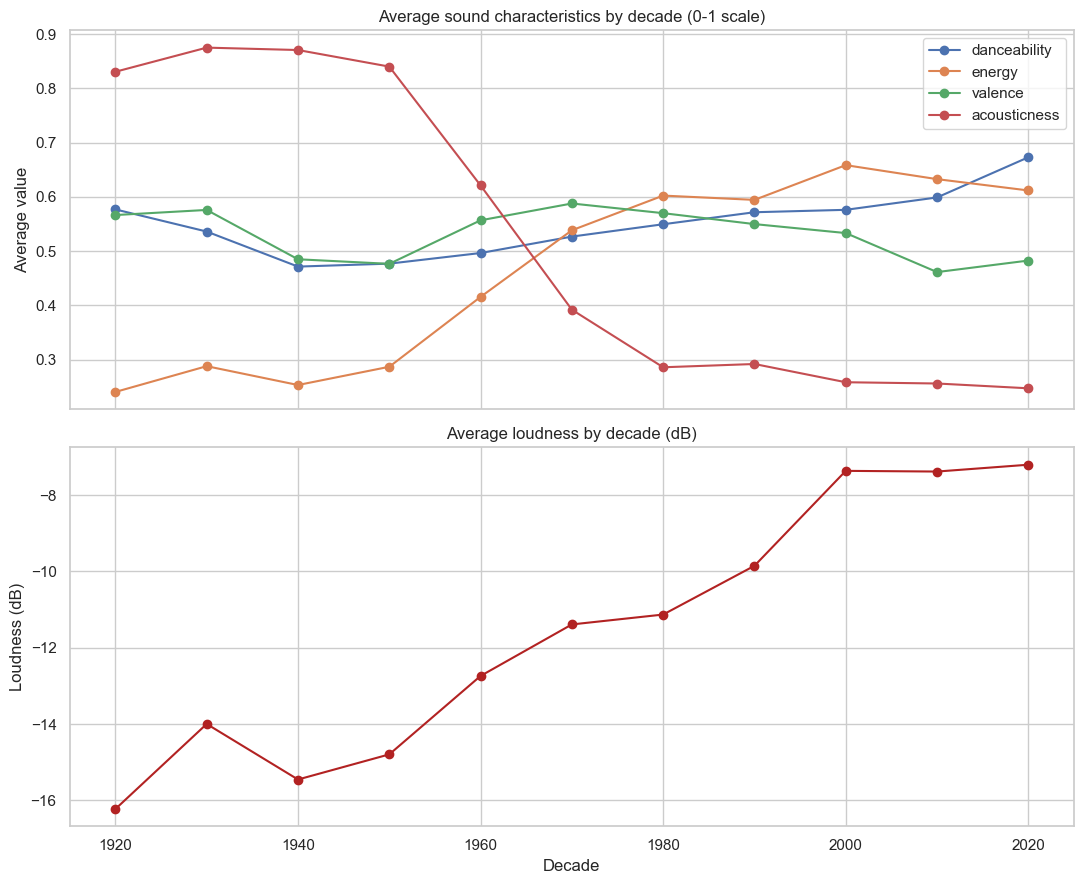

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

# Panel 1: 0-1 scaled features together
for col in ["danceability", "energy", "valence", "acousticness"]:
    axes[0].plot(decade_trends.index, decade_trends[col], marker="o", label=col)
axes[0].set_title("Average sound characteristics by decade (0-1 scale)")
axes[0].set_ylabel("Average value")
axes[0].legend()

# Panel 2: loudness (dB) plotted separately since its scale is different
axes[1].plot(decade_trends.index, decade_trends["loudness"], marker="o", color="firebrick")
axes[1].set_title("Average loudness by decade (dB)")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Loudness (dB)")

plt.tight_layout()
save_fig(fig, "decade_trends.png")
plt.show()


### Reading this chart

A few patterns tend to show up in this kind of analysis, and are worth
checking your own output against:

- **Loudness has generally increased over time** — this reflects a
  well-documented industry trend often called the "loudness war," where
  tracks have been mixed and mastered to sound louder decade over decade.
- **Acousticness tends to decline** in more recent decades, reflecting the
  shift toward electronic production.
- **Danceability and energy** often show more gradual or mixed trends,
  since these are more influenced by shifting genre popularity (disco,
  hip-hop, EDM, etc.) than by any single consistent trend.



## 2.2 Has music gotten more or less "positive" sounding over time?

`valence` measures how musically positive/cheerful a track sounds. This is
one of the more interesting features to track on its own, since it touches
on questions people are naturally curious about (e.g. "is modern music
sadder than older music?").

Saved: ../outputs/figures\valence_by_decade.png


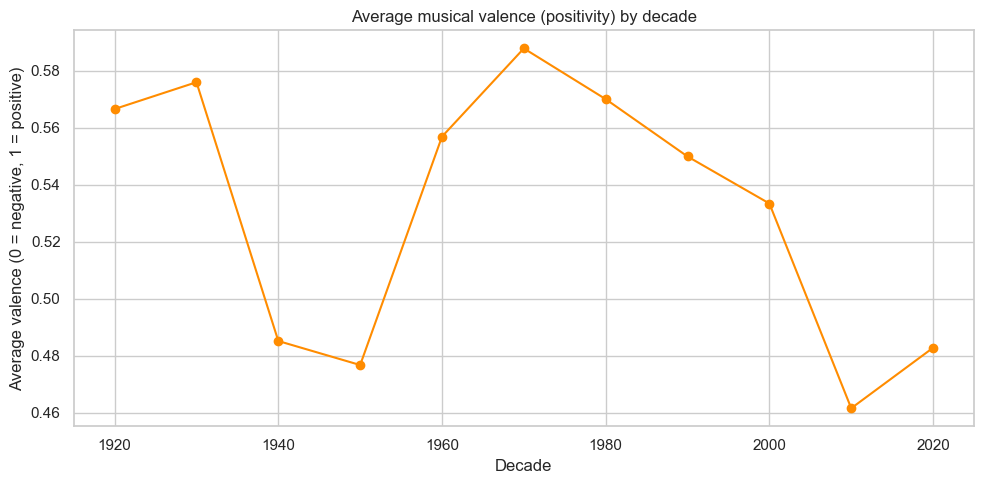

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(decade_trends.index, decade_trends["valence"], marker="o", color="darkorange")
ax.set_title("Average musical valence (positivity) by decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Average valence (0 = negative, 1 = positive)")
plt.tight_layout()
save_fig(fig, "valence_by_decade.png")
plt.show()


The emotional tone of popular music has shifted over time. After reaching a high point in the 1970s, average musical positivity has steadily declined, indicating a trend toward more neutral or emotionally subdued songs in recent decades.

## 2.3 How do audio features relate to each other?

Before we move on to clustering in Step 3, it's worth understanding which
audio features tend to move together. Two features that are strongly
correlated don't add much independent information to a clustering model —
this is useful context to have before deciding which features to include.

Saved: ../outputs/figures\feature_correlation_heatmap.png


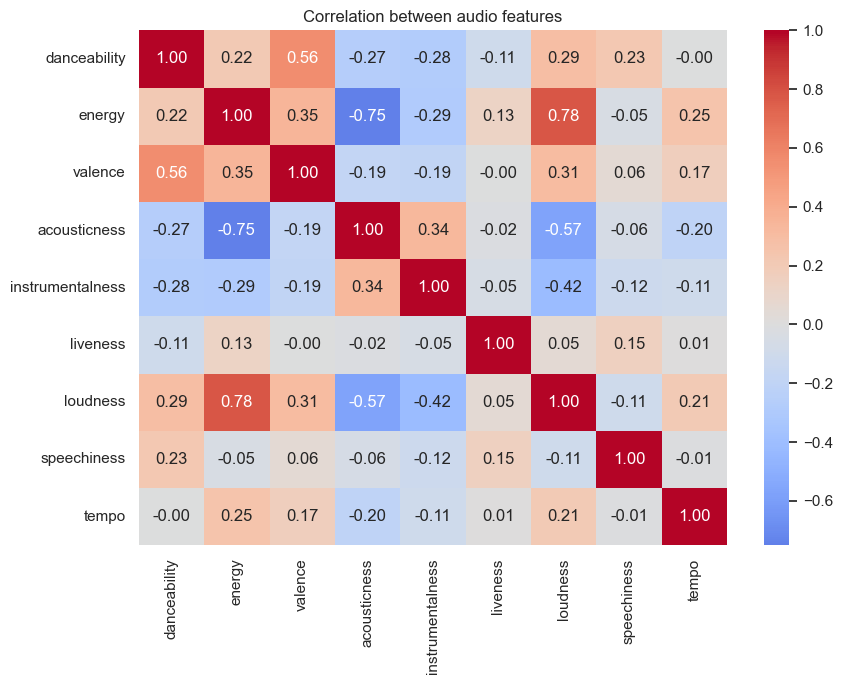

In [5]:
features = ["danceability", "energy", "valence", "acousticness",
            "instrumentalness", "liveness", "loudness", "speechiness", "tempo"]

corr = audio_df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between audio features")
plt.tight_layout()
save_fig(fig, "feature_correlation_heatmap.png")
plt.show()


### Reading this chart

Look for the strongest relationships (values close to +1 or -1). A common
pattern in this kind of data is a strong **positive** correlation between
`energy` and `loudness` (louder tracks tend to feel more energetic) and a
strong **negative** correlation between `energy` and `acousticness`
(acoustic tracks tend to be lower-energy). We'll keep this in mind in Step
3 — if two features are almost perfectly correlated, including both in a
clustering model doesn't add much beyond including one.

## 2.4 Which genres are most common?

Switching to the genre & metadata dataset now. Genres in this dataset are
stored per *artist*, as a list (e.g. `['pop', 'dance pop']`), so before we
can count them we need to "unpack" every artist's genre list into
individual genre tags.

In [6]:
def parse_genres(genre_str):
    """Safely parse a string like "['pop', 'dance pop']" into a real list."""
    if pd.isna(genre_str):
        return []
    try:
        parsed = ast.literal_eval(genre_str)
        return parsed if isinstance(parsed, list) else [genre_str]
    except (ValueError, SyntaxError):
        # Handle the older format that isn't wrapped in brackets, e.g. "moombahton"
        return [g.strip() for g in str(genre_str).split(",")]

genre_df["genre_list"] = genre_df["artist_genres"].apply(parse_genres)

# Count genres at the artist level (not per-track) so one prolific artist
# doesn't over-represent their genre just by having many tracks in the dataset
artist_genre_map = genre_df.drop_duplicates("artist_name")[["artist_name", "genre_list"]]
all_genres = [g for genre_list in artist_genre_map["genre_list"] for g in genre_list if g]

genre_counts = Counter(all_genres)
top_genres = pd.Series(genre_counts).sort_values(ascending=False).head(20)
top_genres


country               99
soundtrack            88
rock                  39
dark r&b              35
anime                 29
hypertechno           28
medieval              27
classic rock          27
old school hip hop    26
classic country       26
slap house            24
hip hop               23
east coast hip hop    23
acoustic country      22
k-pop                 21
r&b                   20
celtic                19
rap                   19
indie                 18
art pop               18
dtype: int64

Saved: ../outputs/figures\top_genres.png


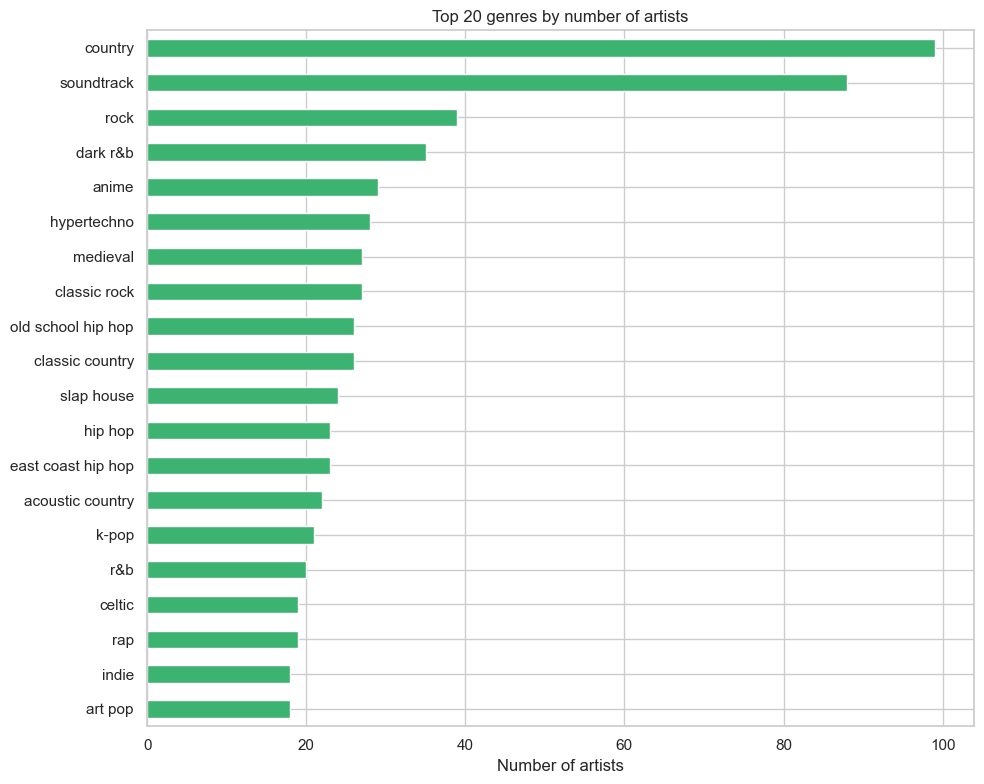

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
top_genres.sort_values().plot(kind="barh", ax=ax, color="mediumseagreen")
ax.set_title("Top 20 genres by number of artists")
ax.set_xlabel("Number of artists")
plt.tight_layout()
save_fig(fig, "top_genres.png")
plt.show()


## 2.5 Which artists are most prominent?

We'll look at this two ways: by **follower count** (audience size) and by
**Spotify's own popularity score** (recent listening activity), since
these can tell different stories — a legacy artist might have huge
followers but lower current popularity, for example.

In [11]:
top_by_followers = (
    genre_df.drop_duplicates("artist_name")
    .nlargest(15, "artist_followers")[["artist_name", "artist_followers", "artist_popularity"]]
)
top_by_followers


,artist_name,artist_followers,artist_popularity
2,Taylor Swift,145396321.0,100.0
8,Ed Sheeran,122773292.0,88.0
3,Billie Eilish,118692183.0,90.0
196,The Weeknd,112918137.0,93.0
32,Ariana Grande,107374593.0,90.0
81,Eminem,104517308.0,88.0
146,Drake,103039388.0,95.0
43,Bad Bunny,102500980.0,95.0
72,Justin Bieber,85008100.0,91.0
248,BTS,81181104.0,85.0


Saved: ../outputs/figures\top_artists_by_followers.png


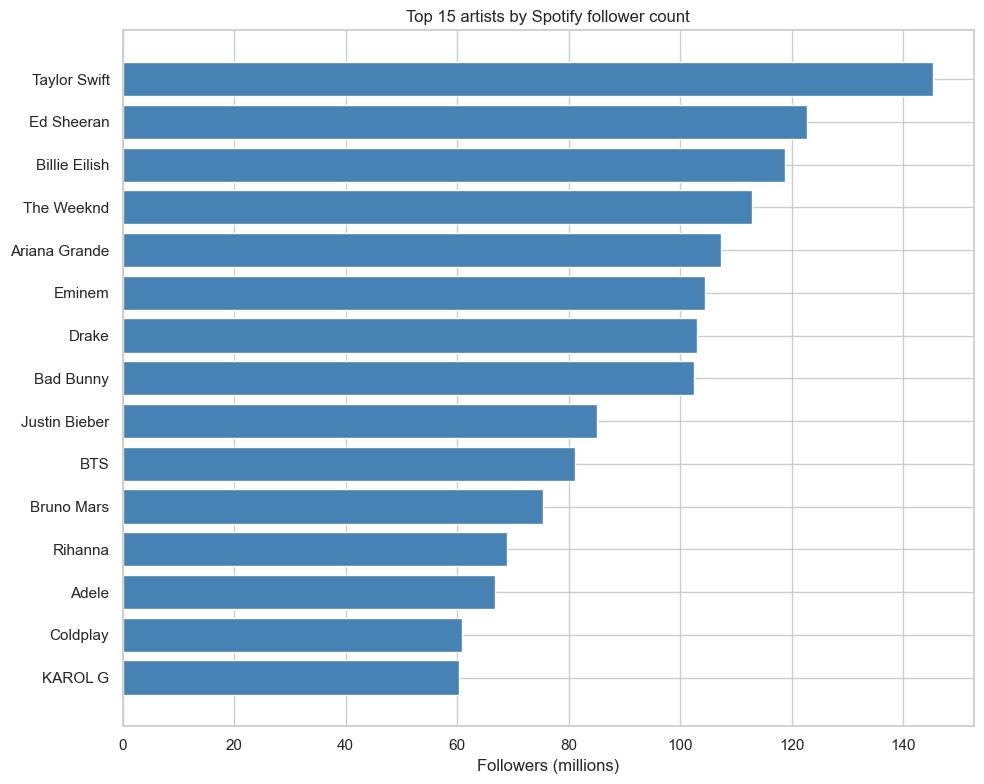

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_data = top_by_followers.sort_values("artist_followers")
ax.barh(plot_data["artist_name"], plot_data["artist_followers"] / 1_000_000, color="steelblue")
ax.set_xlabel("Followers (millions)")
ax.set_title("Top 15 artists by Spotify follower count")
plt.tight_layout()
save_fig(fig, "top_artists_by_followers.png")
plt.show()


## 2.6 Word clouds

Word clouds aren't a rigorous analytical tool, but they're a genuinely
useful way to give a reader an *immediate* visual sense of what dominates
a dataset, before they've read a single number. We'll build two: one for
genres, one for artists — both sized by frequency/prominence.

Saved: ../outputs/figures\genre_wordcloud.png


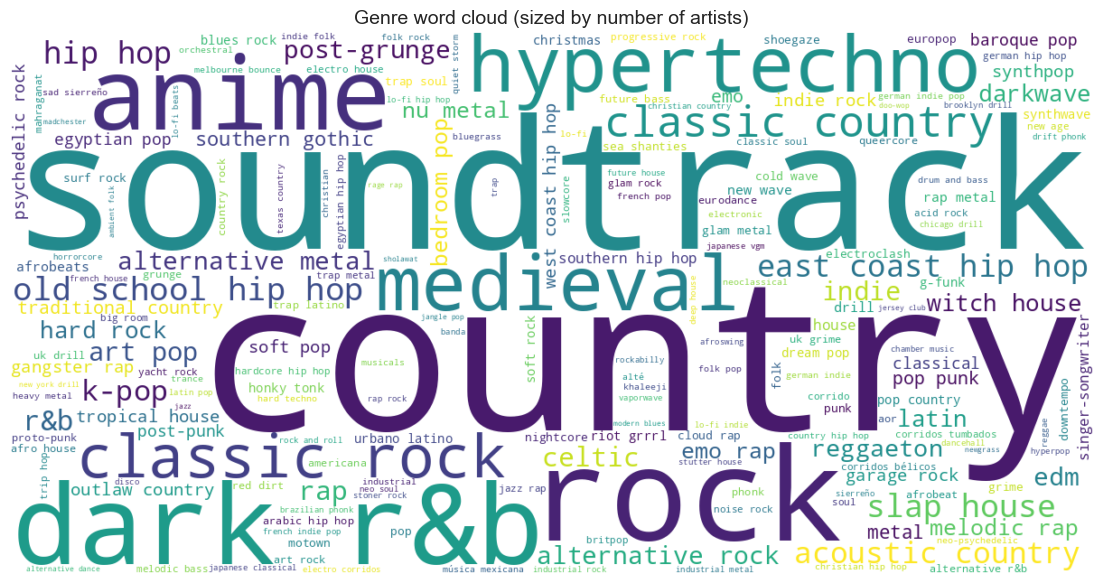

In [13]:
genre_freq = dict(genre_counts)

fig, ax = plt.subplots(figsize=(12, 6))
wc = WordCloud(width=1200, height=600, background_color="white",
               colormap="viridis").generate_from_frequencies(genre_freq)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Genre word cloud (sized by number of artists)", fontsize=14)
plt.tight_layout()
save_fig(fig, "genre_wordcloud.png")
plt.show()


Saved: ../outputs/figures\artist_wordcloud.png


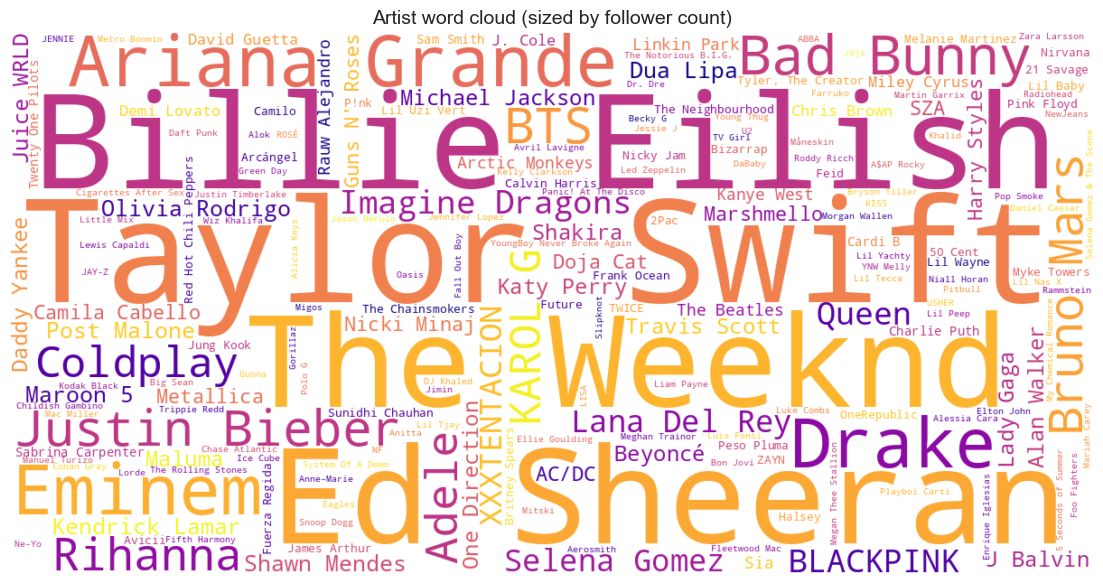

In [14]:
artist_freq = (
    genre_df.drop_duplicates("artist_name")
    .set_index("artist_name")["artist_followers"]
    .dropna()
    .to_dict()
)

fig, ax = plt.subplots(figsize=(12, 6))
wc = WordCloud(width=1200, height=600, background_color="white",
               colormap="plasma").generate_from_frequencies(artist_freq)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Artist word cloud (sized by follower count)", fontsize=14)
plt.tight_layout()
save_fig(fig, "artist_wordcloud.png")
plt.show()


## 2.7 Does popularity relate to any audio characteristics?

As a bridge into Step 3, it's worth asking: do more popular songs actually
sound different from less popular ones? We can check this within the
audio-features dataset itself, since it has both `popularity` and the full
set of sound features.

Saved: ../outputs/figures\popularity_vs_features.png


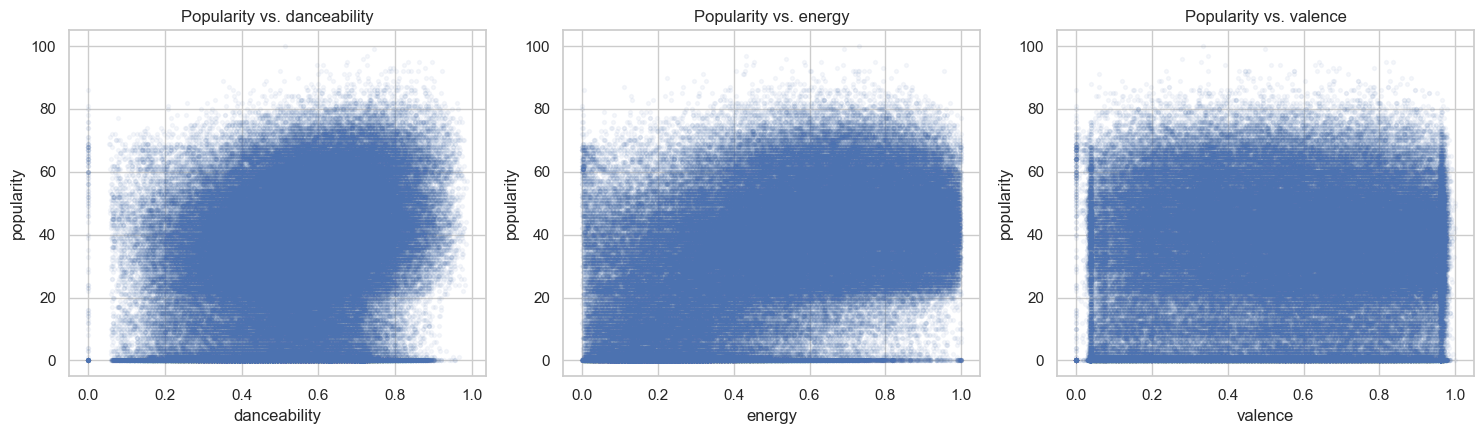

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, feature in zip(axes, ["danceability", "energy", "valence"]):
    ax.scatter(audio_df[feature], audio_df["popularity"], alpha=0.05, s=8)
    ax.set_xlabel(feature)
    ax.set_ylabel("popularity")
    ax.set_title(f"Popularity vs. {feature}")

plt.tight_layout()
save_fig(fig, "popularity_vs_features.png")
plt.show()


### Reading this chart

These scatter plots are deliberately drawn with high transparency
(`alpha=0.05`) because with 170,000 overlapping points, a normal scatter
plot would just look like a solid block of color. The faint plotting lets
denser regions show through as visibly darker patches, which is what
actually reveals the pattern (or lack of one). If you see no strong
diagonal shape in these plots, that itself is a real finding: it suggests
popularity is driven more by factors outside this dataset (marketing,
artist fame, playlist placement) than by the song's raw sound
characteristics alone.

## Summary

- **Decade trends**: sound characteristics like loudness and acousticness
  show clear, explainable shifts over the 20th and 21st centuries (see
  Section 2.1 for the specific pattern found in this dataset).
- **Feature correlations**: some audio features (notably energy and
  loudness) are strongly related to each other, which will inform feature
  selection in Step 3's clustering.
- **Genres and artists**: pop-adjacent genres and major mainstream artists
  dominate the metadata dataset, which is expected given how the dataset
  was likely collected (popular/mainstream catalog coverage rather than a
  random sample of all Spotify content).
- **Popularity vs. sound**: no single audio feature strongly predicts
  popularity on its own — a useful reminder that a recommendation system
  built purely on sound similarity is answering a different question than
  "what's popular."

All charts from this notebook are saved in `../outputs/figures/` for reuse

## Next steps

Step 3 will use the correlation findings from Section 2.3 to inform which
audio features to include in a K-Means clustering model, grouping songs by
sound rather than by pre-existing genre labels.
